In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded")

Libraries loaded


In [ ]:
customers  = pd.read_csv("customers.csv")
orders     = pd.read_csv("orders.csv")
deliveries = pd.read_csv("deliveries.csv")
drivers    = pd.read_csv("drivers.csv")
vehicles   = pd.read_csv("vehicles.csv")
hubs       = pd.read_csv("hubs.csv")
incidents  = pd.read_csv("incidents.csv")
complaints = pd.read_csv("complaints.csv")
app_events = pd.read_csv("app_events.csv")

print("Shapes:")
for name, df in [("customers", customers), ("orders", orders),
                  ("deliveries", deliveries), ("drivers", drivers),
                  ("vehicles", vehicles), ("hubs", hubs),
                  ("incidents", incidents), ("complaints", complaints),
                  ("app_events", app_events)]:
    print(f"  {name}: {df.shape}")

Shapes:
  customers: (650, 9)
  orders: (1250, 11)
  deliveries: (950, 13)
  drivers: (170, 8)
  vehicles: (120, 8)
  hubs: (8, 5)
  incidents: (280, 7)
  complaints: (320, 10)
  app_events: (640, 10)


In [ ]:
print("=== MISSING VALUES ===")
for name, df in [("customers", customers), ("orders", orders),
                  ("deliveries", deliveries), ("vehicles", vehicles)]:
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    if len(missing) > 0:
        print(f"\n{name}:")
        print(missing)

=== MISSING VALUES ===

customers:
loyalty_score        20
preferred_channel    13
dtype: int64

orders:
booking_channel    25
dtype: int64

deliveries:
delivery_completed_at            19
customer_rating_post_delivery    14
dtype: int64

vehicles:
battery_health_pct    4
dtype: int64


In [ ]:
def clean_zone(val):
    if pd.isna(val):
        return val
    return str(val).strip().upper()

customers["home_zone"]     = customers["home_zone"].apply(clean_zone)
orders["pickup_zone"]      = orders["pickup_zone"].apply(clean_zone)
orders["dropoff_zone"]     = orders["dropoff_zone"].apply(clean_zone)
drivers["base_zone"]       = drivers["base_zone"].apply(clean_zone)
vehicles["assigned_zone"]  = vehicles["assigned_zone"].apply(clean_zone)
hubs["zone"]               = hubs["zone"].apply(clean_zone)
app_events["zone_context"] = app_events["zone_context"].apply(clean_zone)

print("Zones standardised")
print("Unique zones in orders:", orders["pickup_zone"].unique())

Zones standardised
Unique zones in orders: ['AIRPORT' 'NORTH' 'WEST' 'RIVERSIDE' 'CENTRAL' 'SOUTH' 'EAST' 'CTR']


In [ ]:
date_cols = {
    "orders":      ["order_created_at"],
    "deliveries":  ["dispatch_time"],
    "complaints":  ["created_at"],
    "app_events":  ["event_timestamp"],
    "customers":   ["signup_date"],
    "vehicles":    ["commission_date"],
    "incidents":   ["reported_at"]
}

for df_name, cols in date_cols.items():
    df = eval(df_name)
    for col in cols:
        df[col] = pd.to_datetime(df[col], errors='coerce')

print("Datetime columns parsed")

Datetime columns parsed


In [ ]:
 deliveries["is_failed"]  = (deliveries["delivery_status"] == "Failed").astype(int)
deliveries["is_delayed"] = (deliveries["delivery_status"] == "Delayed").astype(int)
deliveries["has_override"] = (deliveries["manual_route_override_count"] > 0).astype(int)

 deliveries["dispatch_hour"] = pd.to_datetime(
    deliveries["dispatch_time"], errors='coerce').dt.hour

print("Feature engineering complete")
print(deliveries[["delivery_id","is_failed","is_delayed",
                   "has_override","dispatch_hour"]].head())

Feature engineering complete
  delivery_id  is_failed  is_delayed  has_override  dispatch_hour
0     DL00001          1           0             1             10
1     DL00002          0           0             1             18
2     DL00003          0           0             0             20
3     DL00004          0           1             0             23
4     DL00005          0           0             1             11


In [ ]:
orders["order_hour"]  = orders["order_created_at"].dt.hour
orders["order_month"] = orders["order_created_at"].dt.month
orders["order_day"]   = orders["order_created_at"].dt.day_name()

print(orders[["order_id","order_hour","order_month","order_day"]].head())

  order_id  order_hour  order_month order_day
0   O00001          14            8   Tuesday
1   O00002          22            5   Tuesday
2   O00003          14            9   Tuesday
3   O00004          17            1  Saturday
4   O00005          19            2    Monday


              failure_rate  failures  total
service_type                               
Business             0.198        25    126
Medical              0.148        16    108
Passenger            0.145        38    262
Retail               0.125        28    224
Parcel               0.109        25    230


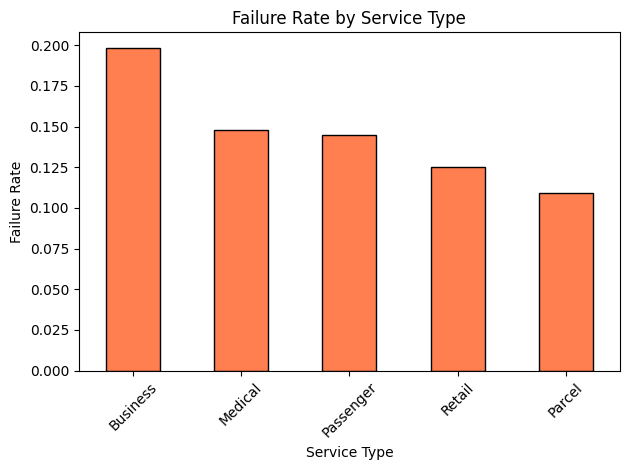

In [ ]:
merged = deliveries.merge(orders, on="order_id", how="left")

failure_by_service = (merged.groupby("service_type")["is_failed"]
                            .agg(["mean","sum","count"])
                            .rename(columns={"mean":"failure_rate",
                                             "sum":"failures",
                                             "count":"total"})
                            .round(3)
                            .sort_values("failure_rate", ascending=False))

print(failure_by_service)

failure_by_service["failure_rate"].plot(kind="bar", color="coral", edgecolor="black")
plt.title("Failure Rate by Service Type")
plt.ylabel("Failure Rate")
plt.xlabel("Service Type")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

=== APP EVENT ANALYSIS ===
event_type
track_order                    138
eta_refresh                    105
search_route                    99
chat_opened                     88
delivery_instruction_update     75
payment_retry                   69
chat_escalated                  38
cancel_attempt                  28
Name: count, dtype: int64

                              mean  median   max
event_type                                      
delivery_instruction_update  496.3   446.0  1285
chat_opened                  478.3   416.5  1690
chat_escalated               478.1   411.0  1402
payment_retry                472.7   440.0  1701
track_order                  460.7   427.0  1660
search_route                 456.5   457.0  1265
eta_refresh                  452.2   440.0  1285
cancel_attempt               417.1   414.0  1039


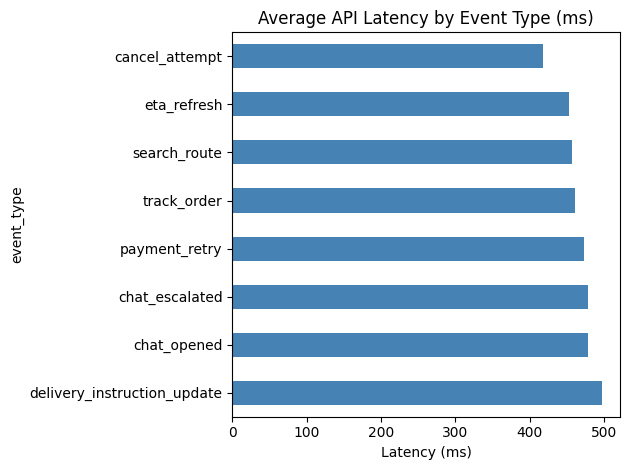

In [ ]:
print("=== APP EVENT ANALYSIS ===")
print(app_events["event_type"].value_counts())
print()

# Average latency by event type
latency = (app_events.groupby("event_type")["api_latency_ms"]
                     .agg(["mean","median","max"])
                     .round(1)
                     .sort_values("mean", ascending=False))
print(latency)

latency["mean"].plot(kind="barh", color="steelblue")
plt.title("Average API Latency by Event Type (ms)")
plt.xlabel("Latency (ms)")
plt.tight_layout()
plt.show()

In [ ]:
complaints_enriched = (complaints
    .merge(orders[["order_id","service_type","pickup_zone",
                   "priority_level","order_value"]],
           on="order_id", how="left")
    .merge(customers[["customer_id","home_zone",
                       "customer_type","loyalty_score"]],
           on="customer_id", how="left"))

print(complaints_enriched.shape)
print(complaints_enriched.head(3))

(320, 17)
  complaint_id customer_id order_id complaint_type  channel severity  \
0       CP0001       C0464   O00814       AppIssue      App     High   
1       CP0002       C0056   O00628   MissedPickup    Phone   Medium   
2       CP0003       C0469   O00384          Delay  Chatbot     High   

           created_at status  resolution_days  compensation_amount  \
0 2025-03-30 02:36:00   Open               11                23.99   
1 2024-11-07 10:05:00   Open                4                21.64   
2 2024-01-02 15:47:00   Open               16                26.41   

  service_type pickup_zone priority_level  order_value home_zone  \
0    Passenger        EAST         Medium        27.90   AIRPORT   
1    Passenger   RIVERSIDE         Medium        52.85     NORTH   
2      Medical         CTR            Low        12.58     NORTH   

  customer_type  loyalty_score  
0    Enterprise           28.8  
1      Consumer           71.1  
2      Consumer            NaN  


                   count  total_compensation  avg_compensation  \
complaint_type                                                   
Delay                101             1696.84             18.05   
MissedPickup          64             1423.40             22.59   
AppIssue              53              980.72             19.61   
DriverBehaviour       51              973.06             21.15   
Billing               16              381.94             23.87   
Damage                15              359.73             23.98   
SupportExperience     20              342.50             17.12   

                   avg_resolution_days  
complaint_type                          
Delay                             7.26  
MissedPickup                      7.64  
AppIssue                          8.60  
DriverBehaviour                   8.16  
Billing                           7.75  
Damage                           11.33  
SupportExperience                 7.45  


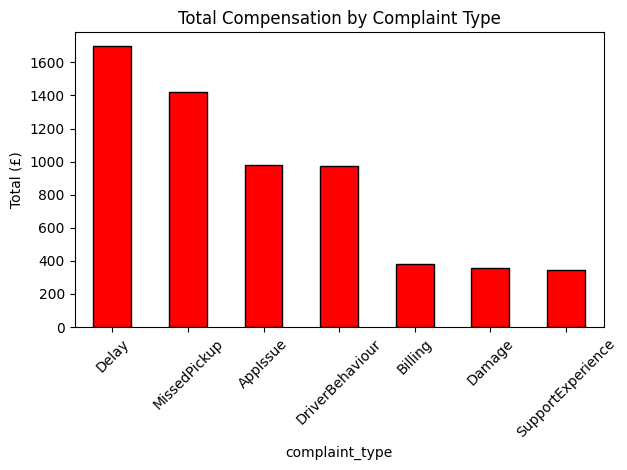

In [ ]:
comp_by_type = (complaints_enriched
    .groupby("complaint_type")
    .agg(
        count=("complaint_id","count"),
        total_compensation=("compensation_amount","sum"),
        avg_compensation=("compensation_amount","mean"),
        avg_resolution_days=("resolution_days","mean")
    )
    .round(2)
    .sort_values("total_compensation", ascending=False))

print(comp_by_type)

comp_by_type["total_compensation"].plot(kind="bar", color="red", edgecolor="black")
plt.title("Total Compensation by Complaint Type")
plt.ylabel("Total (£)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
import json

app_events_sorted = app_events.sort_values(["customer_id","session_id","event_timestamp"])

mongo_docs = []

for (cust_id, session_id), group in app_events_sorted.groupby(["customer_id","session_id"]):
    events = []
    for _, row in group.iterrows():
        events.append({
            "event_id":       row["event_id"],
            "event_type":     row["event_type"],
            "timestamp":      str(row["event_timestamp"]),
            "device_type":    row["device_type"],
            "zone_context":   row["zone_context"],
            "api_latency_ms": int(row["api_latency_ms"]) if pd.notna(row["api_latency_ms"]) else None,
            "success":        bool(row["success_flag"]) if pd.notna(row["success_flag"]) else None
        })

    # Get customer info
    cust_info = customers[customers["customer_id"] == cust_id].to_dict("records")
    cust_data = cust_info[0] if cust_info else {}

    doc = {
        "customer_id":    cust_id,
        "session_id":     session_id,
        "customer_type":  cust_data.get("customer_type"),
        "home_zone":      cust_data.get("home_zone"),
        "loyalty_score":  cust_data.get("loyalty_score"),
        "events":         events,
        "total_events":   len(events),
        "session_start":  events[0]["timestamp"] if events else None
    }
    mongo_docs.append(doc)

print(f"Created {len(mongo_docs)} session documents")
print("\nSample document:")
print(json.dumps(mongo_docs[0], indent=2))

Created 640 session documents

Sample document:
{
  "customer_id": "C0003",
  "session_id": "S43719",
  "customer_type": "Consumer",
  "home_zone": "EAST",
  "loyalty_score": 75.9,
  "events": [
    {
      "event_id": "AE00609",
      "event_type": "payment_retry",
      "timestamp": "2025-06-27 12:45:00",
      "device_type": "iOS",
      "zone_context": "RIVERSIDE",
      "api_latency_ms": 715,
      "success": true
    }
  ],
  "total_events": 1,
  "session_start": "2025-06-27 12:45:00"
}


In [ ]:
complaint_docs = []

for _, comp in complaints.iterrows():
    # Get order info
    order_info = orders[orders["order_id"] == comp["order_id"]].to_dict("records")
    order_data = order_info[0] if order_info else {}

    # Get customer info
    cust_info = customers[customers["customer_id"] == comp["customer_id"]].to_dict("records")
    cust_data = cust_info[0] if cust_info else {}

    # Get related delivery
    deliv_info = deliveries[deliveries["order_id"] == comp["order_id"]].to_dict("records")
    deliv_data = deliv_info[0] if deliv_info else {}

    doc = {
        "complaint_id":   comp["complaint_id"],
        "created_at":     str(comp["created_at"]),
        "complaint_type": comp["complaint_type"],
        "severity":       comp["severity"],
        "status":         comp["status"],
        "channel":        comp["channel"],
        "resolution_days":    comp.get("resolution_days"),
        "compensation_amount": comp.get("compensation_amount"),
        "customer": {
            "customer_id":   comp["customer_id"],
            "customer_type": cust_data.get("customer_type"),
            "home_zone":     cust_data.get("home_zone"),
            "loyalty_score": cust_data.get("loyalty_score"),
            "account_status": cust_data.get("account_status")
        },
        "order": {
            "order_id":       comp["order_id"],
            "service_type":   order_data.get("service_type"),
            "pickup_zone":    order_data.get("pickup_zone"),
            "dropoff_zone":   order_data.get("dropoff_zone"),
            "order_value":    order_data.get("order_value"),
            "priority_level": order_data.get("priority_level")
        },
        "delivery": {
            "delivery_id":    deliv_data.get("delivery_id"),
            "delivery_status": deliv_data.get("delivery_status"),
            "manual_route_override_count": deliv_data.get("manual_route_override_count"),
            "customer_rating_post_delivery": deliv_data.get("customer_rating_post_delivery")
        }
    }
    complaint_docs.append(doc)

print(f"Created {len(complaint_docs)} complaint documents")
print("\nSample:")
print(json.dumps(complaint_docs[0], indent=2, default=str))

Created 320 complaint documents

Sample:
{
  "complaint_id": "CP0001",
  "created_at": "2025-03-30 02:36:00",
  "complaint_type": "AppIssue",
  "severity": "High",
  "status": "Open",
  "channel": "App",
  "resolution_days": 11,
  "compensation_amount": 23.99,
  "customer": {
    "customer_id": "C0464",
    "customer_type": "Enterprise",
    "home_zone": "AIRPORT",
    "loyalty_score": 28.8,
    "account_status": "Dormant"
  },
  "order": {
    "order_id": "O00814",
    "service_type": "Passenger",
    "pickup_zone": "EAST",
    "dropoff_zone": "RIVERSIDE",
    "order_value": 27.9,
    "priority_level": "Medium"
  },
  "delivery": {
    "delivery_id": "DL00426",
    "delivery_status": "OnTime",
    "manual_route_override_count": 1,
    "customer_rating_post_delivery": 4.57
  }
}


In [ ]:
# Save both document collections as JSON
with open("session_documents.json", "w") as f:
    json.dump(mongo_docs, f, indent=2, default=str)

with open("complaint_documents.json", "w") as f:
    json.dump(complaint_docs, f, indent=2, default=str)

print("Saved session_documents.json")
print("Saved complaint_documents.json")
print("Download these — you will import them into MongoDB Atlas in Part 4")

Saved session_documents.json
Saved complaint_documents.json
Download these — you will import them into MongoDB Atlas in Part 4


In [ ]:
from google.colab import files
files.download("session_documents.json")
files.download("complaint_documents.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>